In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os

### Load datasets

#### Global Dataset

In [10]:
global_df = pd.read_csv('../PharmacyTransactionalDataset/global_test_set.csv')
global_df

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
0,1195586,1062,A.M-E.C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
1,1195586,1063,R.A-C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
2,1195586,8.90425E+12,istovin 20mg,Capsule,3,2,0,4/7/2024,2:51PM,Drug
3,1195586,4.26022E+12,caelin %2 sulfur,Soap,1,1,1,4/7/2024,2:51PM,Supply
4,1195586,4.26012E+12,TMS forte 800/160mg,Tablet,1,2,2,4/7/2024,2:51PM,Drug
...,...,...,...,...,...,...,...,...,...,...
240586,1195491,Auto-227,Lafaf 15cm,NaN,1,3,3,1/16/2024,5:12PM,Drug
240587,1195491,6.2911E+12,adol 120mg100ml / julphar,Suspension,1,1,1,1/16/2024,5:11PM,Drug
240588,1195491,6.25116E+12,uciderm 15gm / philadelphia,ointment,1,1,1,1/16/2024,5:11PM,Drug
240589,1195501,Auto-350,DIBASE 100.000 I.U./1ML,Injection,6,2,0,2/7/2024,5:25PM,Drug


In [11]:
global_df.shape

(240591, 10)

In [12]:
global_df.dropna(axis=0, how='any', inplace=True)

#### City Datasets

In [14]:
#Combine zone datasets
def combineZoneDataset(cityNum : int, zoneNum : int):
    base_path_zone = f"../PharmacyTransactionalDataset\\City{cityNum}\\Zone{zoneNum}"
    combine_df_zone = []

    for csv in sorted(os.listdir(base_path_zone)):
        file_path = os.path.join(base_path_zone, csv)
        pharmacy_id = csv.split("_")[0][-1]
        zonal_df = pd.read_csv(file_path)
        zonal_df["pharmacy_id"] = pharmacy_id
        combine_df_zone.append(zonal_df)

    zonal_combined_df = pd.concat(combine_df_zone, ignore_index=True)
    zonal_combined_df.dropna(axis=0, how='any', inplace=True)
    zonal_combined_df.to_csv(f"../PharmacyTransactionalDataset\\City{cityNum}\\C{cityNum}_Z{zoneNum}.csv", index=False)


In [15]:
#Combine city datasets
def combineCityDataset(cityNum : int):
    base_path_city = f"../PharmacyTransactionalDataset\\City{cityNum}"
    combine_df_city = []

    for csv in sorted(os.listdir(base_path_city)):
        if csv.startswith("C") and csv.endswith(".csv"):
            file_path = os.path.join(base_path_city, csv)
            zone_id = csv.split("_")[1][1]
            zonal_df = pd.read_csv(file_path)
            zonal_df["zone_id"] = zone_id
            combine_df_city.append(zonal_df)

    city_combined_df = pd.concat(combine_df_city, ignore_index=True)
    city_combined_df.dropna(axis=0, how='any', inplace=True)
    city_combined_df.to_csv(f"../PharmacyTransactionalDataset\\City{cityNum}_allZones.csv", index=False)

In [16]:
for city_num in range(1, 4):
    for zone_num in range(1, 4):
        combineZoneDataset(city_num, zone_num)
    combineCityDataset(city_num)

In [17]:
c1_df = pd.read_csv('../PharmacyTransactionalDataset/City1_allZones.csv')
c2_df = pd.read_csv('../PharmacyTransactionalDataset/City2_allZones.csv')
c3_df = pd.read_csv('../PharmacyTransactionalDataset/City3_allZones.csv')

In [18]:
c1_df.shape, c2_df.shape, c3_df.shape

((666016, 12), (668380, 12), (667446, 12))

### Data Visualization

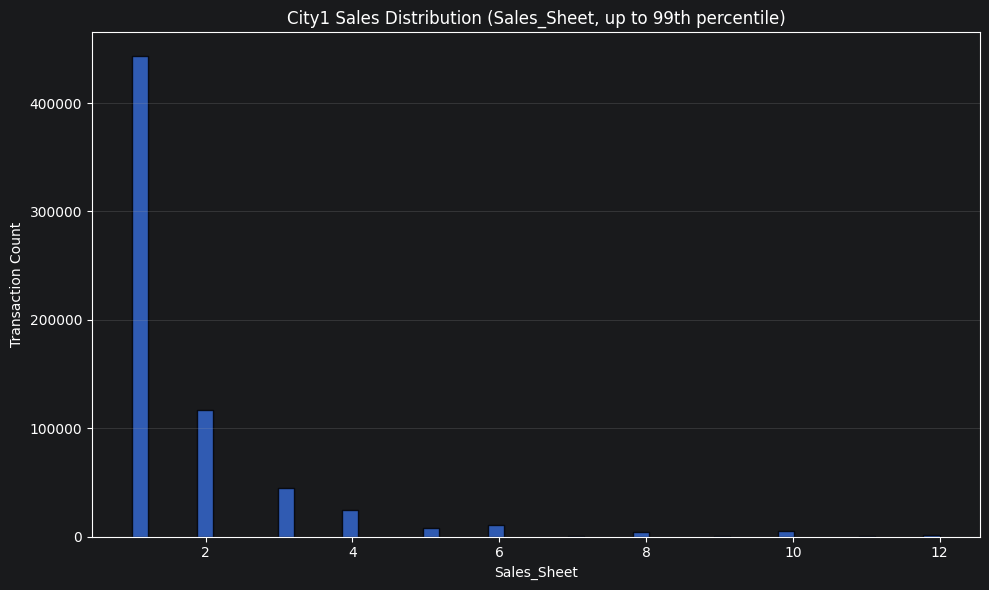

In [19]:
# Sales metric
sales = c1_df["Sales_Sheet"].dropna()

# Clip extreme outliers for a readable distribution plot
p99 = sales.quantile(0.99)
sales_plot = sales[sales <= p99]

plt.figure(figsize=(10, 6))
plt.hist(sales_plot, bins=50, edgecolor="black", alpha=0.8)
plt.title("City1 Sales Distribution (Sales_Sheet, up to 99th percentile)")
plt.xlabel("Sales_Sheet")
plt.ylabel("Transaction Count")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()